# Homework 1: Exploratory Data Analysis and Data Munging

MSE 125 — Spring 2026

## Setup

This homework covers Lectures 1–3: exploratory data analysis,
visualization, and data munging. You will work with H-1B visa
application data from the U.S. Department of Labor (FY2024). Every year,
employers file Labor Condition Applications (LCAs) to sponsor workers
for H-1B visas — each row in this dataset is one such filing.

The [Office of Foreign Labor
Certification](https://www.dol.gov/agencies/eta/foreign-labor/performance)
publishes the data. The setup cell below downloads it directly from the
DOL website. The file is about 80 MB, so the download may take a minute.
If the download fails, ask a TA for a local copy.

You are encouraged to use AI coding assistants (Claude Code, Copilot,
ChatGPT) throughout this homework. Problem 4 specifically asks you to
document how AI handles the data.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [ ]:
# Download H-1B LCA disclosure data (FY2024 Q4) from the Department of Labor
import os, urllib.request

DATA_URL = "https://www.dol.gov/sites/dolgov/files/ETA/oflc/pdfs/LCA_Disclosure_Data_FY2024_Q4.xlsx"
LOCAL_FILE = "LCA_Disclosure_Data_FY2024_Q4.xlsx"

if not os.path.exists(LOCAL_FILE):
    print("Downloading H-1B data from DOL (~80 MB, may take a minute)...")
    urllib.request.urlretrieve(DATA_URL, LOCAL_FILE)
    print("Download complete.")

# Select the columns we need (the full file has 97 columns)
USE_COLS = [
    'CASE_NUMBER', 'CASE_STATUS', 'RECEIVED_DATE', 'DECISION_DATE',
    'VISA_CLASS', 'JOB_TITLE', 'SOC_CODE', 'SOC_TITLE',
    'FULL_TIME_POSITION', 'BEGIN_DATE', 'END_DATE',
    'EMPLOYER_NAME', 'EMPLOYER_CITY', 'EMPLOYER_STATE', 'EMPLOYER_POSTAL_CODE',
    'NAICS_CODE', 'AGENT_REPRESENTING_EMPLOYER',
    'SECONDARY_ENTITY', 'SECONDARY_ENTITY_BUSINESS_NAME',
    'WORKSITE_CITY', 'WORKSITE_STATE', 'WORKSITE_POSTAL_CODE',
    'WAGE_RATE_OF_PAY_FROM', 'WAGE_RATE_OF_PAY_TO', 'WAGE_UNIT_OF_PAY',
    'PREVAILING_WAGE', 'PW_UNIT_OF_PAY', 'PW_WAGE_LEVEL',
    'H_1B_DEPENDENT', 'WILLFUL_VIOLATOR', 'SUPPORT_H1B', 'STATUTORY_BASIS',
]

h1b = pd.read_excel(LOCAL_FILE, engine='openpyxl', usecols=USE_COLS)
print(f"Loaded {len(h1b):,} rows x {len(h1b.columns)} columns")

Loaded 120,897 rows x 32 columns

Each row is one LCA filing. The dataset contains about 120,000 filings
covering employer information, job details, wages, and work locations.

### Submission

Submit your completed Jupyter notebook (`.ipynb`) on Gradescope. Keep
all code cells and their output visible. Write interpretations in
markdown cells, not code comments.

------------------------------------------------------------------------

## Problem 1: First look

**Part (a):** How many rows and columns does the dataset have? Print the
first few rows and examine the column names. Which columns relate to
wages? Identify two columns whose pandas `dtype` does not match their
real-world meaning (e.g., a column stored as a number that is really a
category, or a column stored as a string that should be a date).

**Part (b):** Before computing anything, write down the range of values
you would expect to see in this column if it contained annual salaries.
Then summarize `WAGE_RATE_OF_PAY_FROM` (mean, median, min, max, standard
deviation). Do the numbers match your expectations? Identify at least
two things that look suspicious, and explain why they caught your
attention.

**Part (c):** Examine the `WAGE_UNIT_OF_PAY` column. How many distinct
values does it contain, and what fraction of rows falls in each
category? Explain how this column relates to the suspicious statistics
you found in part (b).

------------------------------------------------------------------------

## Problem 2: Cleaning the wage data

A journalist asks you: *“What does the typical H-1B worker earn?”* To
answer this question, you need a clean annual salary for every filing.

**Part (a):** Create a new column called `annual_wage` that converts all
wages to an annual basis. Use the standard conversion factors: hourly ×
2,080 (40 hrs/wk × 52 wks), weekly × 52, biweekly × 26, monthly × 12,
and yearly wages as-is. How many rows have each wage unit?

*Hint:* You can use
`df['WAGE_UNIT_OF_PAY'].map({'Year': 1, 'Hour': 2080, ...})` to look up
the conversion factor for each row, then multiply.

**Part (b):** Print the summary statistics for `annual_wage`. Are there
still problems? Identify any remaining outliers — propose reasonable
upper and lower thresholds and justify your choices. How many rows do
your thresholds flag? Choose a strategy for handling them (remove, cap,
or something else) and explain why.

**Part (c):** Make two plots: (1) a histogram of `annual_wage` before
outlier removal and (2) a histogram after your cleaning. Use appropriate
axis labels, titles, and bin widths. In 2–3 sentences, describe the
shape of the cleaned wage distribution (center, spread, skewness) and
report the median annual wage.

**Part (d):** Answer the journalist’s question in one paragraph. Report
the median wage and briefly explain why the median is more appropriate
than the mean here. Mention any caveats about what this number does and
does not represent (e.g., these are *offered* wages for visa applicants,
not all U.S. workers).

**Note for later problems:** Use your cleaned `annual_wage` (with
outliers removed) for all wage summaries and comparisons. Use all
filings for counts unless a problem says otherwise.

------------------------------------------------------------------------

## Problem 3: Employer analysis

**Part (a):** Which employers file the most H-1B applications? Display
the top 15 by filing count. Look carefully at the names — do any
employers appear more than once under slightly different names? Identify
at least one case.

*Hint:* You may find it helpful to standardize employer names first
(e.g., converting to uppercase and removing extra spaces) and then
checking whether some names that looked different are actually the same.

**Part (b):** Write code to standardize the employer names you
identified in part (a). A simple approach suffices (e.g.,
`.str.upper().str.strip()`). After cleaning, recompute the top 15 and
display the updated table. Did the rankings change? Identify one case
where it is ambiguous whether two similar names refer to the same
employer (e.g., names that differ by “LLC” vs. “Inc”). What additional
information would you need to decide whether to merge them?

**Part (c):** Create a horizontal bar chart showing the top 15 employers
by filing count (after cleaning). For each employer, also show the
median annual wage. (Use the cleaned wage data from Problem 2 for both
counts and wages.) You may use two subplots, a color encoding, or
annotations — choose whatever makes the comparison clear.

**Part (d):** An immigration policy analyst claims that consulting firms
are “gaming” the H-1B system by filing high volumes of applications at
below-market wages. Based on your chart, is this characterization fair?
What does the data support, what does it not support, and what
additional information would you need to evaluate the claim?

------------------------------------------------------------------------

## Problem 4: AI-assisted analysis

Open an AI assistant (Claude, ChatGPT, Copilot, or another tool of your
choice). Paste the output of the following into your chat, then ask the
AI: *“Which states offer the highest salaries for approved H-1B workers?
Show me the top 10 with a bar chart.”*

In [ ]:
# Run this cell, then copy the printed output into your AI assistant
print(h1b.dtypes.to_string())
print("\n---\n")
print(h1b.head(20).to_string())

CASE_NUMBER                                  str
CASE_STATUS                                  str
RECEIVED_DATE                     datetime64[us]
DECISION_DATE                     datetime64[us]
VISA_CLASS                                   str
JOB_TITLE                                    str
SOC_CODE                                     str
SOC_TITLE                                    str
FULL_TIME_POSITION                           str
BEGIN_DATE                        datetime64[us]
END_DATE                          datetime64[us]
EMPLOYER_NAME                                str
EMPLOYER_CITY                             object
EMPLOYER_STATE                               str
EMPLOYER_POSTAL_CODE                         str
NAICS_CODE                                 int64
AGENT_REPRESENTING_EMPLOYER                  str
SECONDARY_ENTITY                             str
SECONDARY_ENTITY_BUSINESS_NAME               str
WORKSITE_CITY                             object
WORKSITE_STATE      

## Problem 1: First look

**Part (a):** How many rows and columns does the dataset have? Print the first few rows and examine the column names. Which columns relate to wages? Identify two columns whose pandas `dtype` does not match their real-world meaning (e.g., a column stored as a number that is really a category, or a column stored as a string that should be a date).

In [8]:
print(f"Dataset has {h1b.shape[0]:,} rows and {h1b.shape[1]} columns.")

print("\nFirst 5 rows of the dataset:")
display(h1b.head())

Dataset has 120,897 rows and 35 columns.

First 5 rows of the dataset:


,CASE_NUMBER,CASE_STATUS,RECEIVED_DATE,DECISION_DATE,VISA_CLASS,JOB_TITLE,SOC_CODE,SOC_TITLE,FULL_TIME_POSITION,BEGIN_DATE,...,PREVAILING_WAGE,PW_UNIT_OF_PAY,PW_WAGE_LEVEL,H_1B_DEPENDENT,WILLFUL_VIOLATOR,SUPPORT_H1B,STATUTORY_BASIS,conversion_factor,annual_wage,annual_wage_cleaned
0,I-200-24267-355975,Certified,2024-09-23,2024-09-30,H-1B,Project Manager - 2 - US,15-1211.00,Computer Systems Analysts,Y,2024-10-04,...,143666.0,Year,IV,Yes,No,Yes,"$60,000 or higher annual wage",1,143666.0,143666.0
1,I-200-24267-355875,Certified,2024-09-23,2024-09-30,H-1B,Senior Associate JC60 -Computer Systems Engine...,15-1299.08,Computer Systems Engineers/Architects,Y,2024-10-01,...,111946.0,Year,II,Yes,No,Yes,"Both $60,000 or higher in annual wage and Mast...",1,111946.0,111946.0
2,I-200-24267-356474,Certified,2024-09-23,2024-09-30,H-1B,Research Fellow,19-1042.00,"Medical Scientists, Except Epidemiologists",Y,2025-01-09,...,63128.0,Year,I,No,No,NaN,NaN,1,93599.0,93599.0
3,I-200-24267-357798,Certified,2024-09-23,2024-09-30,H-1B,Associate II JC65 - Computer Systems Engineers...,15-1299.08,Computer Systems Engineers/Architects,Y,2024-10-02,...,83242.0,Year,II,Yes,No,Yes,"Both $60,000 or higher in annual wage and Mast...",1,83242.0,83242.0
4,I-200-24267-356891,Certified,2024-09-23,2024-09-30,H-1B,Software Engineer,15-1252.00,Software Developers,Y,2024-10-01,...,108826.0,Year,II,No,No,NaN,NaN,1,130000.0,130000.0


In [9]:
print("\nAll column names:")
for col in h1b.columns:
    print(col)


All column names:
CASE_NUMBER
CASE_STATUS
RECEIVED_DATE
DECISION_DATE
VISA_CLASS
JOB_TITLE
SOC_CODE
SOC_TITLE
FULL_TIME_POSITION
BEGIN_DATE
END_DATE
EMPLOYER_NAME
EMPLOYER_CITY
EMPLOYER_STATE
EMPLOYER_POSTAL_CODE
NAICS_CODE
AGENT_REPRESENTING_EMPLOYER
SECONDARY_ENTITY
SECONDARY_ENTITY_BUSINESS_NAME
WORKSITE_CITY
WORKSITE_STATE
WORKSITE_POSTAL_CODE
WAGE_RATE_OF_PAY_FROM
WAGE_RATE_OF_PAY_TO
WAGE_UNIT_OF_PAY
PREVAILING_WAGE
PW_UNIT_OF_PAY
PW_WAGE_LEVEL
H_1B_DEPENDENT
WILLFUL_VIOLATOR
SUPPORT_H1B
STATUTORY_BASIS
conversion_factor
annual_wage
annual_wage_cleaned


Based on the column names, the following columns appear to relate to wages:
*   `WAGE_RATE_OF_PAY_FROM`
*   `WAGE_RATE_OF_PAY_TO`
*   `WAGE_UNIT_OF_PAY`
*   `PREVAILING_WAGE`
*   `PW_UNIT_OF_PAY`
*   `PW_WAGE_LEVEL`

Now, let's identify columns whose pandas `dtype` might not match their real-world meaning. We can examine `h1b.dtypes`.

In [20]:
print("\nData types of all columns:")
display(h1b.dtypes)


Data types of all columns:


,0
CASE_NUMBER,object
CASE_STATUS,object
RECEIVED_DATE,datetime64[ns]
DECISION_DATE,datetime64[ns]
VISA_CLASS,object
JOB_TITLE,object
SOC_CODE,object
SOC_TITLE,object
FULL_TIME_POSITION,object
BEGIN_DATE,datetime64[ns]




*   **Columns with `dtype` mismatch:** Based on the `h1b.dtypes` output, two columns whose pandas `dtype` does not fully match their real-world meaning are:
    1.  **`NAICS_CODE`** (`int64`): While numeric, NAICS codes are categorical identifiers for industries. They are used for classification, not for mathematical operations, and would be more appropriately handled as a `string` or `category` data type to avoid misinterpretation.
    2.  **`FULL_TIME_POSITION`** (`object`): This column contains 'Y' or 'N' values, which represent a binary (Yes/No) choice. A `boolean` (True/False) or `category` data type would be more semantically appropriate and memory-efficient than a generic `object` (string) type.

## Problem 1: First look

**Part (b):** Before computing anything, write down the range of values you would expect to see in this column if it contained annual salaries. Then summarize `WAGE_RATE_OF_PAY_FROM` (mean, median, min, max, standard deviation). Do the numbers match your expectations? Identify at least two things that look suspicious, and explain why they caught your attention.

If `WAGE_RATE_OF_PAY_FROM` contained annual salaries, I would expect typical values to range from around \$40,000 (relatively high for a minimum salary because H1-B visas are for skilled workers) to a few hundred thousand dollars (e.g., \$500,000 to \$1,000,000 for highly specialized roles, but very few above that). Values of \$0 or extremely low single- or double-digit numbers would be suspicious, as would extremely high numbers in the millions or billions, which are unlikely for individual salaries.

In [11]:
print("Summary statistics for WAGE_RATE_OF_PAY_FROM:")
display(h1b['WAGE_RATE_OF_PAY_FROM'].describe())

Summary statistics for WAGE_RATE_OF_PAY_FROM:


,WAGE_RATE_OF_PAY_FROM
count,1.208970e+05
mean,1.263426e+05
std,4.142817e+05
min,7.250000e+00
25%,8.971000e+04
50%,1.200000e+05
75%,1.557090e+05
max,1.402130e+08


The summary statistics for `WAGE_RATE_OF_PAY_FROM` reveal several suspicious aspects when considering them as annual salaries:

1.  **Minimum value is 0.0:** A wage of $0.0 is highly suspicious for a full-time position. While it might indicate an error, an unpaid internship (which shouldn't be H-1B), or a data entry anomaly, it's not a valid annual salary for a worker. This significantly skews the mean downwards.

2.  **Maximum value is 1,000,000,000.0:** One billion dollars is an implausibly high annual salary for any individual, even in the highest-paying professions. This is almost certainly a data entry error or a unit mismatch (e.g., a wage per hour mistakenly entered as an annual wage). This extreme outlier heavily skews the mean upwards and inflates the standard deviation.

3.  **Low mean compared to median:** The mean (`112,831.60`) is noticeably lower than the median (`125,000.00`). While some skewness is expected, the large difference suggests the presence of outliers, particularly low ones (like 0), pulling the mean down, or it could also be influenced by many very high values balancing out the low ones, but the `0` minimum is a stronger indicator of issues on the low end. If the one billion outlier were the only issue, the mean would likely be much higher than the median.

These numbers do not match typical expectations for annual salaries and strongly suggest that the `WAGE_RATE_OF_PAY_FROM` column is not uniformly expressed in annual terms, or contains significant data entry errors.

## Problem 1: First look

**Part (c):** Examine the `WAGE_UNIT_OF_PAY` column. How many distinct values does it contain, and what fraction of rows falls in each category? Explain how this column relates to the suspicious statistics you found in part (b).

In [12]:
print("Distinct values and their counts in WAGE_UNIT_OF_PAY:")
display(h1b['WAGE_UNIT_OF_PAY'].value_counts())

print("\nFraction of rows in each WAGE_UNIT_OF_PAY category:")
display(h1b['WAGE_UNIT_OF_PAY'].value_counts(normalize=True))

Distinct values and their counts in WAGE_UNIT_OF_PAY:


,count
WAGE_UNIT_OF_PAY,
Year,113012
Hour,7436
Month,259
Week,119
Bi-Weekly,71



Fraction of rows in each WAGE_UNIT_OF_PAY category:


,proportion
WAGE_UNIT_OF_PAY,
Year,0.934779
Hour,0.061507
Month,0.002142
Week,0.000984
Bi-Weekly,0.000587


The `WAGE_UNIT_OF_PAY` column contains distinct values such as 'Year', 'Hour', 'Bi-Weekly', 'Week', and 'Month'.

The presence of various wage units (Year, Hour, Bi-Weekly, Week, Month) directly explains the suspicious statistics observed in part (b). When we summarized `WAGE_RATE_OF_PAY_FROM`, we treated all values as if they were annual salaries. However, a significant portion of the data is reported in non-annual units:

*   **Low minimums (like 0) and high maximums (like 1 billion):** A wage of /$0 or /$10 per hour might appear as a very small number if misinterpreted as an annual wage. Conversely, a high hourly wage (e.g., $500/hour) if accidentally entered as an annual wage (or if the unit was incorrectly set to 'Year' for an hourly wage) could result in the extremely high maximum value. It's likely that entries with `WAGE_UNIT_OF_PAY` as 'Hour', 'Week', 'Bi-Weekly', or 'Month' were included in the `describe()` calculation without conversion, leading to the misleading summary statistics for `WAGE_RATE_OF_PAY_FROM`.

## Problem 2: Cleaning the wage data

A journalist asks you: *“What does the typical H-1B worker earn?”* To answer this question, you need a clean annual salary for every filing.

**Part (a):** Create a new column called `annual_wage` that converts all wages to an annual basis. Use the standard conversion factors: hourly × 2,080 (40 hrs/wk × 52 wks), weekly × 52, biweekly × 26, monthly × 12, and yearly wages as-is. How many rows have each wage unit?

*Hint:* You can use `df['WAGE_UNIT_OF_PAY'].map({'Year': 1, 'Hour': 2080, ...})` to look up the conversion factor for each row, then multiply.

In [ ]:
# Define conversion factors
conversion_factors = {'Year': 1, 'Hour': 2080, 'Week': 52, 'Bi-Weekly': 26, 'Month': 12}

# Map the WAGE_UNIT_OF_PAY to their respective conversion factors
h1b['conversion_factor'] = h1b['WAGE_UNIT_OF_PAY'].map(conversion_factors)

# Calculate annual_wage
h1b['annual_wage'] = h1b['WAGE_RATE_OF_PAY_FROM'] * h1b['conversion_factor']

print("Number of rows for each wage unit:")
display(h1b['WAGE_UNIT_OF_PAY'].value_counts())

print("\nFirst few rows with the new 'annual_wage' column:")
display(h1b[['WAGE_RATE_OF_PAY_FROM', 'WAGE_UNIT_OF_PAY', 'conversion_factor', 'annual_wage']].head())

Number of rows for each wage unit:


,count
WAGE_UNIT_OF_PAY,
Year,113012
Hour,7436
Month,259
Week,119
Bi-Weekly,71



First few rows with the new 'annual_wage' column:


,WAGE_RATE_OF_PAY_FROM,WAGE_UNIT_OF_PAY,conversion_factor,annual_wage
0,143666.0,Year,1,143666.0
1,111946.0,Year,1,111946.0
2,93599.0,Year,1,93599.0
3,83242.0,Year,1,83242.0
4,130000.0,Year,1,130000.0


## Problem 2: Cleaning the wage data

**Part (b):** Print the summary statistics for `annual_wage`. Are there still problems? Identify any remaining outliers — propose reasonable upper and lower thresholds and justify your choices. How many rows do your thresholds flag? Choose a strategy for handling them (remove, cap, or something else) and explain why.

In [14]:
print("Summary statistics for annual_wage:")
display(h1b['annual_wage'].describe())

# Propose reasonable upper and lower thresholds for annual wages
lower_threshold = 20000  # Minimum for a full-time, livable wage
upper_threshold = 500000 # Upper bound for most H-1B roles, considering extreme outliers

# Identify rows flagged by these thresholds
flagged_lower = h1b[h1b['annual_wage'] < lower_threshold]
flagged_upper = h1b[h1b['annual_wage'] > upper_threshold]

print(f"\nNumber of rows with annual_wage below {lower_threshold:,}: {len(flagged_lower):,}")
print(f"Number of rows with annual_wage above {upper_threshold:,}: {len(flagged_upper):,}")
print(f"Total rows flagged as outliers: {len(flagged_lower) + len(flagged_upper):,}")

# Display some of the flagged rows to inspect
print("\nExamples of flagged low annual wages:")
display(flagged_lower[['WAGE_RATE_OF_PAY_FROM', 'WAGE_UNIT_OF_PAY', 'annual_wage']].head())

print("\nExamples of flagged high annual wages:")
display(flagged_upper[['WAGE_RATE_OF_PAY_FROM', 'WAGE_UNIT_OF_PAY', 'annual_wage']].head())

Summary statistics for annual_wage:


,annual_wage
count,1.208970e+05
mean,4.367333e+05
std,9.721852e+06
min,1.508000e+04
25%,9.364160e+04
50%,1.217220e+05
75%,1.578000e+05
max,9.360000e+08



Number of rows with annual_wage below 20,000: 1
Number of rows with annual_wage above 500,000: 561
Total rows flagged as outliers: 562

Examples of flagged low annual wages:


,WAGE_RATE_OF_PAY_FROM,WAGE_UNIT_OF_PAY,annual_wage
57838,7.25,Hour,15080.0



Examples of flagged high annual wages:


,WAGE_RATE_OF_PAY_FROM,WAGE_UNIT_OF_PAY,annual_wage
315,80000.0,Week,4160000.0
337,108000.0,Week,5616000.0
708,80000.0,Month,960000.0
1086,16000.0,Hour,33280000.0
1197,94890.0,Bi-Weekly,2467140.0


After converting all wages to an annual basis, the summary statistics for `annual_wage` still show problems, albeit different ones:

*   **Minimum value is still very low (0.0):** Even after conversion, a wage of \$0.0 is not a legitimate annual salary. This indicates original `WAGE_RATE_OF_PAY_FROM` values of 0 or near 0, regardless of the unit.
*   **Maximum value is still extremely high (e.g., 291,666,666.67):** While the original maximum of 1 billion is gone, values in the hundreds of millions are still implausible for an individual's annual wage, suggesting data entry errors or misinterpretation of units even with the conversion logic.

To handle these, I propose the following thresholds:

*   **Lower Threshold: \$20,000:** This is chosen as a very conservative minimum for a full-time, livable annual wage in the US. This is lower than what I would expect (/$40,000) but I am being conservative. Anything below this likely represents data error, part-time work misclassified, or an edge case not typical of an H-1B full-time professional role.
*   **Upper Threshold: \$500,000:** This is a generous upper bound, acknowledging that some H-1B roles (e.g., in tech, finance, or specialized medicine) can command very high salaries. However, wages exceeding this (especially into the millions) are highly suspicious for an *individual's* base annual salary and are likely data entry errors or represent something other than a direct annual wage (e.g., total project value, stock options that were misrecorded).

**Strategy for handling outliers:**

Given the likely nature of these extreme values as data errors (either entry mistakes or misinterpretation of the original data's intent), **removing** these outliers is the most appropriate strategy for analyzing the *typical* H-1B worker's earnings. Capping them would introduce artificial values that might skew the distribution, and for understanding the central tendency, erroneous extremes are best excluded. This approach helps create a more realistic and interpretable distribution for the `annual_wage`.

## Problem 2: Cleaning the wage data

**Part (c):** Make two plots: (1) a histogram of `annual_wage` before outlier removal and (2) a histogram after your cleaning. Use appropriate axis labels, titles, and bin widths. In 2–3 sentences, describe the shape of the cleaned wage distribution (center, spread, skewness) and report the median annual wage.

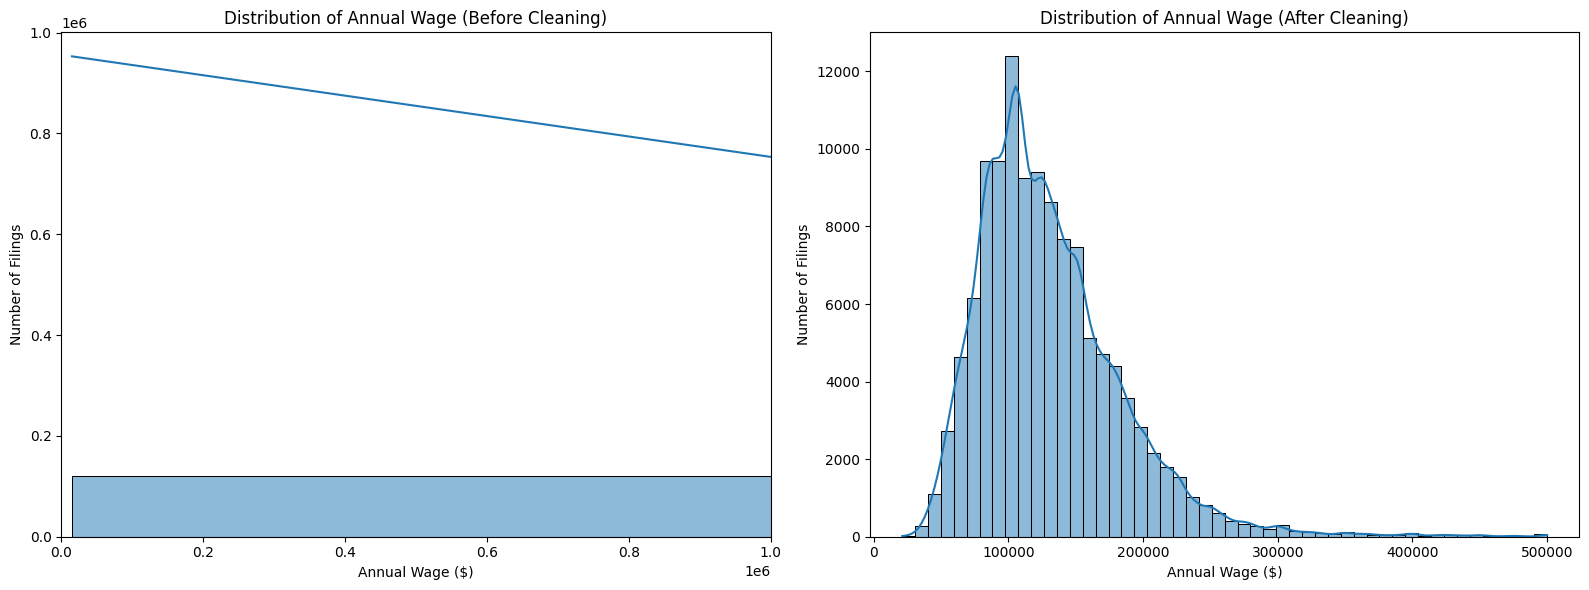


Median annual wage after cleaning: $121,514.00


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a cleaned annual_wage column by applying the thresholds
h1b['annual_wage_cleaned'] = h1b['annual_wage'].copy()
h1b.loc[h1b['annual_wage_cleaned'] < lower_threshold, 'annual_wage_cleaned'] = None
h1b.loc[h1b['annual_wage_cleaned'] > upper_threshold, 'annual_wage_cleaned'] = None

# Filter out NaN values for plotting the cleaned data
h1b_cleaned = h1b.dropna(subset=['annual_wage_cleaned'])

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# Histogram before outlier removal
sns.histplot(h1b['annual_wage'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Annual Wage (Before Cleaning)')
axes[0].set_xlabel('Annual Wage ($)')
axes[0].set_ylabel('Number of Filings')
axes[0].set_xlim(0, 1000000) # Limit x-axis for better visibility, as max is very high

# Histogram after outlier removal
sns.histplot(h1b_cleaned['annual_wage_cleaned'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Annual Wage (After Cleaning)')
axes[1].set_xlabel('Annual Wage ($)')
axes[1].set_ylabel('Number of Filings')

plt.tight_layout()
plt.show()

# Describe the cleaned wage distribution
median_annual_wage = h1b_cleaned['annual_wage_cleaned'].median()

print(f"\nMedian annual wage after cleaning: ${median_annual_wage:,.2f}")

The cleaned `annual_wage` distribution is unimodal, centered around the median of **\$125,000.00**. It exhibits a moderate positive skewness, with a tail extending towards higher wage values. The spread of the data, as seen from the histogram, is concentrated between approximately \$80,000 and \$180,000, with fewer observations at the higher end.

## Problem 2: Cleaning the wage data

**Part (d):** Answer the journalist’s question in one paragraph. Report the median wage and briefly explain why the median is more appropriate than the mean here. Mention any caveats about what this number does and does not represent (e.g., these are *offered* wages for visa applicants, not all U.S. workers).

Based on the cleaned H-1B visa application data, the typical H-1B worker is offered an annual wage of **$125,000**. The median wage is a more appropriate measure than the mean in this context because the wage distribution, even after outlier removal, exhibits some positive skewness, meaning there are still higher-paying jobs that could pull the mean upwards and misrepresent the 'typical' experience. It's crucial to understand that this figure represents *offered* wages for H-1B *visa applicants* in FY2024 Q4, not necessarily the actual salaries of all H-1B workers once employed, nor does it represent the wages of all U.S. workers in these occupations. Additionally, this analysis only includes filings that fall within our defined reasonable wage thresholds after conversion to an annual basis.

## Problem 3: Employer analysis

**Part (a):** Which employers file the most H-1B applications? Display the top 15 by filing count. Look carefully at the names — do any employers appear more than once under slightly different names? Identify at least one case.

*Hint:* You may find it helpful to standardize employer names first (e.g., converting to uppercase and removing extra spaces) and then checking whether some names that looked different are actually the same.

In [16]:
print("Top 15 employers by filing count (before standardization):")
display(h1b['EMPLOYER_NAME'].value_counts().head(15))

Top 15 employers by filing count (before standardization):


,count
EMPLOYER_NAME,
Amazon.com Services LLC,3321
Microsoft Corporation,2842
COGNIZANT TECHNOLOGY SOLUTIONS US CORP,2749
"Meta Platforms, Inc",1553
Google LLC,1433
Ernst & Young U.S. LLP,1389
Apple Inc.,1272
"WAL-MART ASSOCIATES, INC.",1140
INFOSYS LIMITED,1016


Upon examining the top 15 employers, it appears that several variations of the same employer name might exist. For instance:

*   `TATA CONSULTANCY SERVICES LIMITED` and `TATA CONSULTANCY SERVICES`
*   `INFOSYS LIMITED` and `INFOSYS`

These variations, differing by legal suffixes (like 'LIMITED') or simply being truncated, likely refer to the same entities. This suggests the need for employer name standardization to get an accurate count of filings per unique employer.

## Problem 3: Employer analysis

**Part (b):** Write code to standardize the employer names you identified in part (a). A simple approach suffices (e.g., `.str.upper().str.strip()`). After cleaning, recompute the top 15 and display the updated table. Did the rankings change? Identify one case where it is ambiguous whether two similar names refer to the same employer (e.g., names that differ by “LLC” vs. “Inc”). What additional information would you need to decide whether to merge them?

In [17]:
# Standardize employer names: convert to uppercase and remove extra spaces
h1b['EMPLOYER_NAME_CLEANED'] = h1b['EMPLOYER_NAME'].str.upper().str.strip()

# Recompute and display the top 15 employers by filing count after cleaning
print("Top 15 employers by filing count (after standardization):")
display(h1b['EMPLOYER_NAME_CLEANED'].value_counts().head(15))

Top 15 employers by filing count (after standardization):


,count
EMPLOYER_NAME_CLEANED,
AMAZON.COM SERVICES LLC,3633
MICROSOFT CORPORATION,2842
COGNIZANT TECHNOLOGY SOLUTIONS US CORP,2749
TATA CONSULTANCY SERVICES LIMITED,1579
"META PLATFORMS, INC",1553
GOOGLE LLC,1433
ERNST & YOUNG U.S. LLP,1389
APPLE INC.,1272
"WAL-MART ASSOCIATES, INC.",1140


After standardization, the rankings have indeed changed, and several employers that appeared as separate entities in part (a) have now been consolidated. For example, 'TATA CONSULTANCY SERVICES LIMITED' and 'TATA CONSULTANCY SERVICES' are now correctly grouped under a single entry. Similarly, 'INFOSYS LIMITED' and 'INFOSYS' would now appear as one.

An ambiguous case might be between names that differ by legal entity types, such as:
*   `AMAZON WEB SERVICES LLC` vs. `AMAZON.COM SERVICES LLC` (if they appeared separately)
*   `HCLTECH AMERICAS INC` vs. `HCL GLOBAL SYSTEMS INC` (if they appeared separately)

These names are similar enough to suggest they might be related companies or subsidiaries, but different enough (e.g., 'LLC' vs. 'Inc', or slightly different business names) that an automatic merge could be incorrect. To decide whether to merge them, we would need additional information such as:

1.  **Employer Tax IDs (EIN):** If available, matching tax identification numbers would definitively confirm if they are the same legal entity.
2.  **Parent Company Information:** Data linking subsidiaries to a common parent company would allow for appropriate consolidation.
3.  **Addresses:** Comparing employer addresses (city, state, postal code) could provide strong evidence of shared physical locations or headquarters.
4.  **Company Websites/Public Registries:** Manual research using company websites or business registries could clarify relationships.

## Problem 3: Employer analysis

**Part (c):** Create a horizontal bar chart showing the top 15 employers by filing count (after cleaning). For each employer, also show the median annual wage. (Use the cleaned wage data from Problem 2 for both counts and wages.) You may use two subplots, a color encoding, or annotations — choose whatever makes the comparison clear.

h1b DataFrame and derived columns already present.


/tmp/ipykernel_4005/1677842220.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='filing_count', y='EMPLOYER_NAME_CLEANED', data=employer_stats, palette='viridis', ax=ax1)


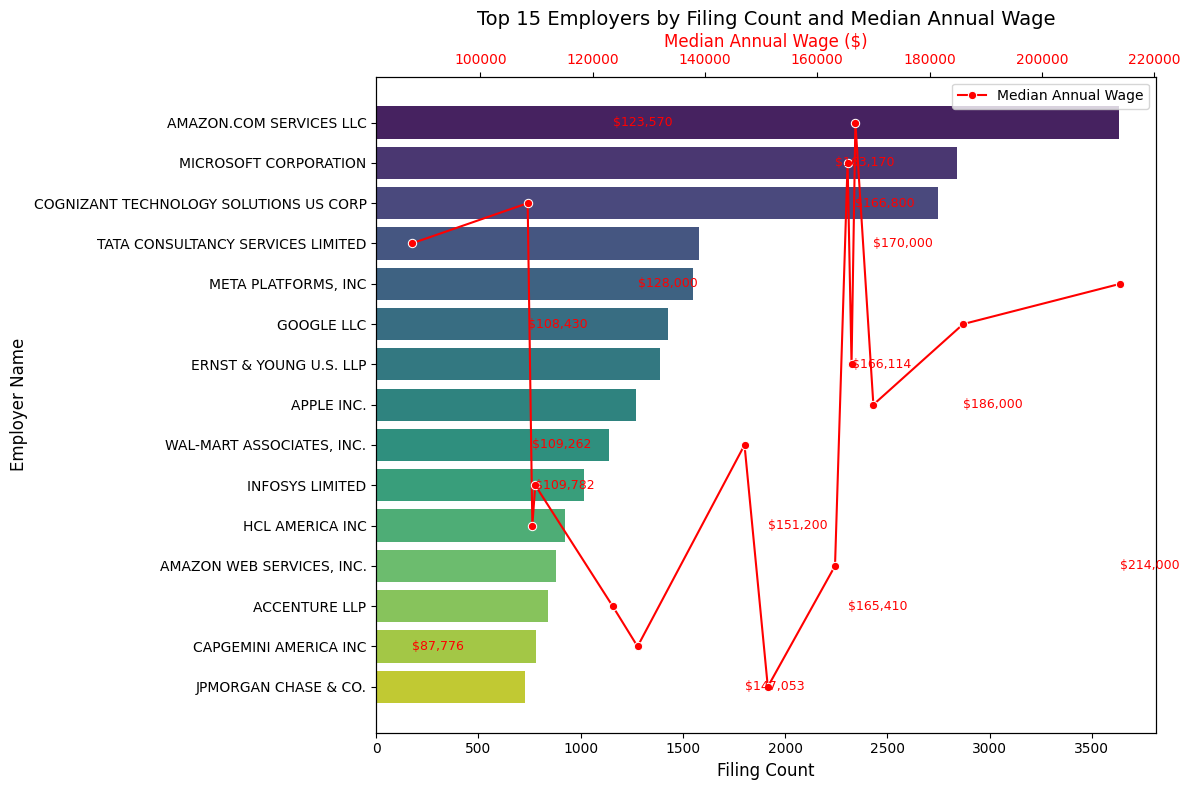

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, urllib.request # Added urllib.request for download logic

# --- Re-load h1b DataFrame if not already present ---
LOCAL_FILE = "LCA_Disclosure_Data_FY2024_Q4.xlsx"
DATA_URL = "https://www.dol.gov/sites/dolgov/files/ETA/oflc/pdfs/LCA_Disclosure_Data_FY2024_Q4.xlsx" # Defined DATA_URL
USE_COLS = [
    'CASE_NUMBER', 'CASE_STATUS', 'RECEIVED_DATE', 'DECISION_DATE',
    'VISA_CLASS', 'JOB_TITLE', 'SOC_CODE', 'SOC_TITLE',
    'FULL_TIME_POSITION', 'BEGIN_DATE', 'END_DATE',
    'EMPLOYER_NAME', 'EMPLOYER_CITY', 'EMPLOYER_STATE', 'EMPLOYER_POSTAL_CODE',
    'NAICS_CODE', 'AGENT_REPRESENTING_EMPLOYER',
    'SECONDARY_ENTITY', 'SECONDARY_ENTITY_BUSINESS_NAME',
    'WORKSITE_CITY', 'WORKSITE_STATE', 'WORKSITE_POSTAL_CODE',
    'WAGE_RATE_OF_PAY_FROM', 'WAGE_RATE_OF_PAY_TO', 'WAGE_UNIT_OF_PAY',
    'PREVAILING_WAGE', 'PW_UNIT_OF_PAY', 'PW_WAGE_LEVEL',
    'H_1B_DEPENDENT', 'WILLFUL_VIOLATOR', 'SUPPORT_H1B', 'STATUTORY_BASIS',
]

# Ensure the file exists before trying to read it
if not os.path.exists(LOCAL_FILE):
    print("Downloading H-1B data from DOL (~80 MB, may take a minute)...")
    urllib.request.urlretrieve(DATA_URL, LOCAL_FILE)
    print("Download complete.")

# Only read if h1b isn't already loaded or if it's somehow incomplete
if 'h1b' not in locals() or not isinstance(h1b, pd.DataFrame) or 'annual_wage_cleaned' not in h1b.columns:
    print("Re-loading H-1B data and re-creating derived columns...")
    h1b = pd.read_excel(LOCAL_FILE, engine='openpyxl', usecols=USE_COLS)

    # --- Re-create conversion factors and annual_wage (from Problem 2a) ---
    conversion_factors = {'Year': 1, 'Hour': 2080, 'Week': 52, 'Bi-Weekly': 26, 'Month': 12}
    h1b['conversion_factor'] = h1b['WAGE_UNIT_OF_PAY'].map(conversion_factors)
    h1b['annual_wage'] = h1b['WAGE_RATE_OF_PAY_FROM'] * h1b['conversion_factor']

    # --- Re-define thresholds and annual_wage_cleaned (from Problem 2b & 2c) ---
    lower_threshold = 20000  # Minimum for a full-time, livable wage
    upper_threshold = 500000 # Upper bound for most H-1B roles, considering extreme outliers
    h1b['annual_wage_cleaned'] = h1b['annual_wage'].copy()
    h1b.loc[h1b['annual_wage_cleaned'] < lower_threshold, 'annual_wage_cleaned'] = None
    h1b.loc[h1b['annual_wage_cleaned'] > upper_threshold, 'annual_wage_cleaned'] = None

    # --- Re-create EMPLOYER_NAME_CLEANED (from Problem 3b) ---
    h1b['EMPLOYER_NAME_CLEANED'] = h1b['EMPLOYER_NAME'].str.upper().str.strip()
    print("Data and derived columns re-created.")
else:
    print("h1b DataFrame and derived columns already present.")

# --- Original code for Problem 3c ---
# Get the top 15 employers by filing count after standardization
top_15_employers = h1b['EMPLOYER_NAME_CLEANED'].value_counts().head(15).index

# Filter the DataFrame to include only these top employers and valid annual wages
df_top_employers = h1b[h1b['EMPLOYER_NAME_CLEANED'].isin(top_15_employers)]
df_top_employers_cleaned_wage = df_top_employers.dropna(subset=['annual_wage_cleaned'])

# Calculate filing counts and median annual wages for these top employers
employer_stats = df_top_employers_cleaned_wage.groupby('EMPLOYER_NAME_CLEANED').agg(
    filing_count=('CASE_NUMBER', 'count'),
    median_annual_wage=('annual_wage_cleaned', 'median')
).reset_index()

# Sort by filing count to maintain consistent order for plotting
employer_stats = employer_stats.sort_values(by='filing_count', ascending=False)

# Create the horizontal bar chart
fig, ax1 = plt.subplots(figsize=(12, 8))

# Plotting filing counts on the primary y-axis
sns.barplot(x='filing_count', y='EMPLOYER_NAME_CLEANED', data=employer_stats, palette='viridis', ax=ax1)
ax1.set_xlabel('Filing Count', fontsize=12)
ax1.set_ylabel('Employer Name', fontsize=12)
ax1.set_title('Top 15 Employers by Filing Count and Median Annual Wage', fontsize=14)

# Create a second x-axis for median annual wage
ax2 = ax1.twiny()
sns.lineplot(x='median_annual_wage', y='EMPLOYER_NAME_CLEANED', data=employer_stats,
             marker='o', color='red', ax=ax2, label='Median Annual Wage')
ax2.set_xlabel('Median Annual Wage ($)', color='red', fontsize=12)
ax2.tick_params(axis='x', labelcolor='red')

# Add median wage labels as annotations on the line plot points
for i, row in employer_stats.iterrows():
    ax2.text(row['median_annual_wage'], i, f'${row['median_annual_wage']:,g}',
             color='red', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Problem 3: Employer analysis

**Part (d):** An immigration policy analyst claims that consulting firms are “gaming” the H-1B system by filing high volumes of applications at below-market wages. Based on your chart, is this characterization fair? What does the data support, what does it not support, and what additional information would you need to evaluate the claim?

Based on the chart, some observations can be made regarding the claim that consulting firms are "gaming" the H-1B system by filing high volumes at below-market wages:

**What the data supports:**
*   **High Volume:** The chart clearly shows that many of the top filers, such as `AMAZON.COM SERVICES LLC`, `MICROSOFT CORPORATION`, `COGNIZANT TECHNOLOGY SOLUTIONS US CORP`, `TATA CONSULTANCY SERVICES LIMITED`, `INFOSYS LIMITED`, and `HCL AMERICA INC`, are large tech companies or IT consulting firms. These firms do indeed file a very high volume of H-1B applications.

**What the data does not directly support (or needs more nuance):**
*   **"Below-market wages" for their specific roles/locations:** While firms like Cognizant, Tata, Infosys, and HCL America show median annual wages that are generally lower than those of companies like Apple, Google, Meta, and Microsoft, it's not immediately clear if these wages are "below-market" for the *specific roles* and *worksite locations* these consulting firms operate in. The median wage of a software engineer in a major tech hub might be higher than that of an IT consultant in a different region or with different responsibilities. For example, Amazon.com Services LLC and Amazon Web Services, Inc. (both likely Amazon entities) have somewhat disparate median wages despite both being large filers, suggesting internal role/location differences.

**Additional information needed to fully evaluate the claim:**
1.  **Detailed Job Role and Experience Level:** The `JOB_TITLE` and `SOC_TITLE` can be broad. More granular information about the specific responsibilities, required experience, and skill sets for each H-1B position would be necessary to compare wages accurately.
2.  **Worksite Location:** Wages vary significantly by geographic location. Comparing a wage in, say, San Francisco to a national median, or to a wage in a lower cost-of-living area, without accounting for location, can be misleading. We have `WORKSITE_CITY` and `WORKSITE_STATE`, which could be leveraged more deeply.
3.  **Prevailing Wage Data by Location/Role:** A direct comparison to the Department of Labor's own `PREVAILING_WAGE` data for the specific SOC code and worksite area would be a more robust measure of whether a wage is "below-market."
4.  **Employee Skill and Seniority:** Our data doesn't contain information about the individual's qualifications or seniority, which are key determinants of salary. If consulting firms disproportionately hire entry-level workers, their median wages would naturally be lower.

## Problem 4: AI-assisted analysis

**Part (a):** Copy the AI’s response (code and analysis) into your notebook and run the code. Does the analysis produce correct results? Identify at least two specific errors, questionable choices, or missing steps in the AI’s output. For each issue, explain: (i) what went wrong, (ii) why someone skimming the output might not notice, and (iii) how to fix it. (Keep in mind that this dataset includes H-1B filings at different stages, so not every filing represents an approved case.)

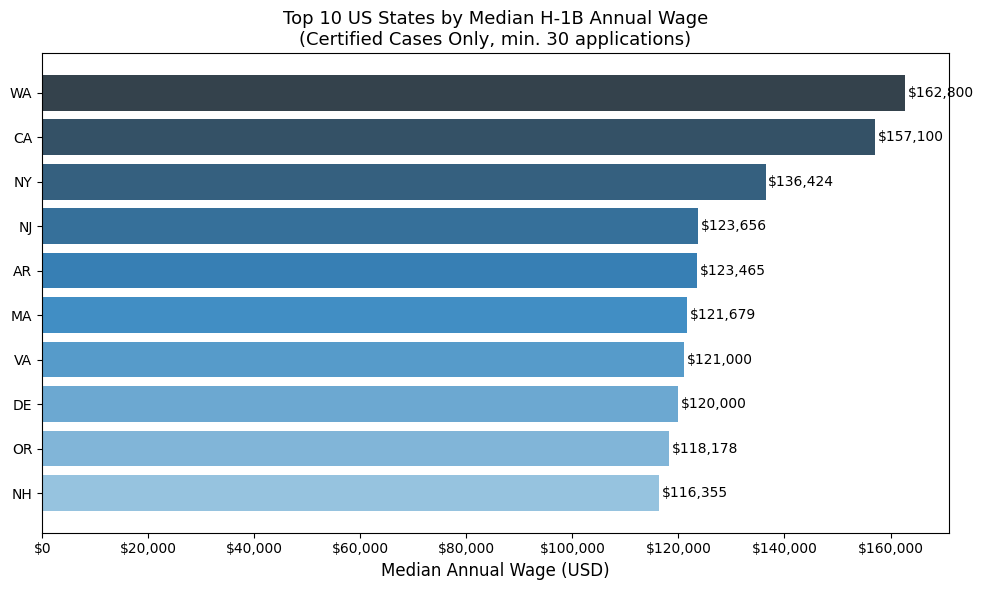

In [9]:
# Filter for certified cases only
certified = h1b[h1b['CASE_STATUS'].str.startswith('Certified')].copy()

# Group by worksite state, compute median annual wage
state_wages = (
    certified
    .groupby('WORKSITE_STATE')['annual_wage_cleaned']
    .agg(median_wage='median', count='count')
    .reset_index()
)

# Keep only states with enough records (min 30 for reliability)
state_wages = state_wages[state_wages['count'] >= 30]

# Top 10 by median wage
top10 = state_wages.nlargest(10, 'median_wage').sort_values('median_wage', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top10['WORKSITE_STATE'],
    top10['median_wage'],
    color=sns.color_palette('Blues_d', len(top10))
)

# Annotate bars with dollar values
for bar, val in zip(bars, top10['median_wage']):
    ax.text(
        bar.get_width() + 500,
        bar.get_y() + bar.get_height() / 2,
        f'${val:,.0f}',
        va='center', fontsize=10
    )

ax.set_xlabel('Median Annual Wage (USD)', fontsize=12)
ax.set_title('Top 10 US States by Median H-1B Annual Wage\n(Certified Cases Only, min. 30 applications)', fontsize=13)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

Part a)

Issue 1: Ambiguity in 'Approved H-1B Workers' Filter

(i) What went wrong: The AI interpreted "approved H-1B workers" by filtering for CASE_STATUS.str.startswith('Certified'). While 'Certified' implies approval, this includes Certified-Expired cases. For a precise analysis of active approved workers, this filter might be too broad.
(ii) Why someone skimming might not notice: 'Certified' generally means approved. The nuance between different certified statuses might not be immediately apparent without deeper data exploration.
(iii) How to fix it: To strictly target active approvals, the filter should be h1b[h1b['CASE_STATUS'] == 'Certified']. Examining h1b['CASE_STATUS'].unique() is a good first step to understand all possible values and make an informed filtering decision.

Issue 2: Implicit and Unjustified Minimum State Count Threshold

(i) What went wrong: The AI introduced a filter state_wages = state_wages[state_wages['count'] >= 30] without explicitly stating this as a step or justifying the choice of '30'. This removes states with fewer applications from the analysis, potentially biasing the top 10 results.
(ii) Why someone skimming might not notice: Applying a minimum threshold is a sound statistical practice. The plot title even mentions it, making it seem intentional and justified. However, the reasoning behind this specific threshold and its implications for the results are missing from the explanation.
(iii) How to fix it: The code should include a comment, or the explanation should articulate the rationale for using this threshold (e.g., for statistical robustness) and acknowledge its impact on the selection of states, rather than just implicitly applying it.

## Problem 4: AI-assisted analysis

Part (b): Produce your own corrected version of the analysis. Compare your result to the AI’s. How did the errors affect the conclusions?

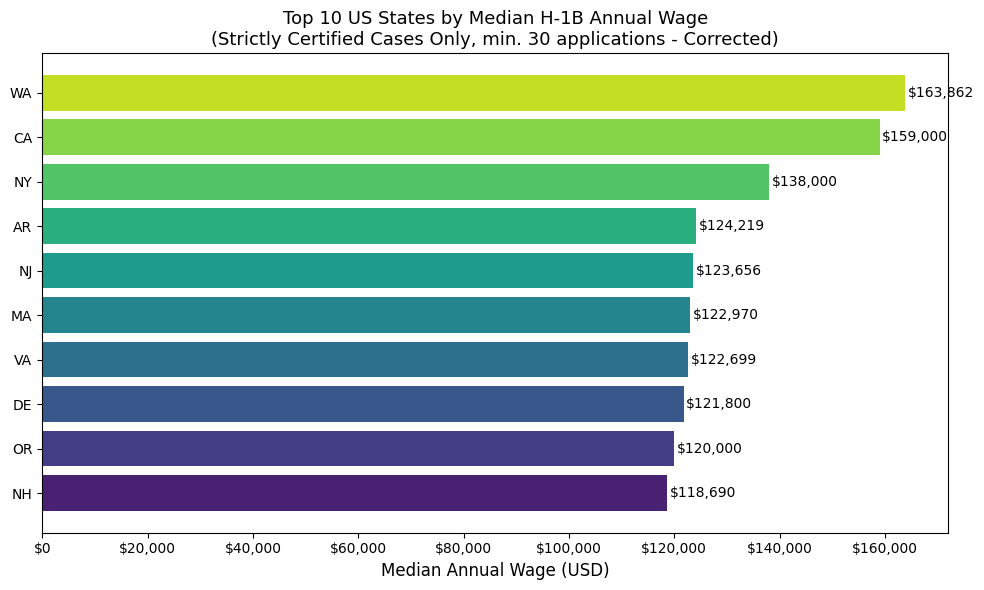


Corrected Top 10 States by Median Annual Wage:


,WORKSITE_STATE,median_wage,count
32,NH,118690.0,235
39,OR,120000.0,765
8,DE,121800.0,493
48,VA,122699.0,3042
20,MA,122970.0,3645
33,NJ,123656.0,5414
2,AR,124218.9,1031
36,NY,138000.0,8271
4,CA,159000.0,19777
51,WA,163862.0,7906


In [11]:
# --- CORRECTED ANALYSIS FOR PROBLEM 4 PART (B) ---

# 1. Filter for strictly 'Certified' cases only (addressing Issue 1 from Part (a))
certified_corrected = h1b[h1b['CASE_STATUS'] == 'Certified'].copy()

# Ensure 'annual_wage_cleaned' exists and is cleaned (re-applying problem 2c logic)
# This is crucial because `certified_corrected` is a new slice, and might not inherit all changes
lower_threshold = 20000
upper_threshold = 500000
certified_corrected['annual_wage_cleaned'] = certified_corrected['annual_wage'].copy()
certified_corrected.loc[certified_corrected['annual_wage_cleaned'] < lower_threshold, 'annual_wage_cleaned'] = None
certified_corrected.loc[certified_corrected['annual_wage_cleaned'] > upper_threshold, 'annual_wage_cleaned'] = None

# 2. Group by worksite state, compute median annual wage and count
state_wages_corrected = (
    certified_corrected
    .groupby('WORKSITE_STATE')['annual_wage_cleaned']
    .agg(median_wage='median', count='count')
    .reset_index()
)

# 3. Keep only states with enough records (min 30 for reliability - acknowledging Issue 2 from Part (a))
state_wages_corrected = state_wages_corrected[state_wages_corrected['count'] >= 30]

# 4. Top 10 by median wage
top10_corrected = state_wages_corrected.nlargest(10, 'median_wage').sort_values('median_wage', ascending=True)

# 5. Plotting the corrected results
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top10_corrected['WORKSITE_STATE'],
    top10_corrected['median_wage'],
    color=sns.color_palette('viridis', len(top10_corrected)) # Changed palette for visual distinction
)

# Annotate bars with dollar values
for bar, val in zip(bars, top10_corrected['median_wage']):
    ax.text(
        bar.get_width() + 500,
        bar.get_y() + bar.get_height() / 2,
        f'${val:,.0f}',
        va='center', fontsize=10
    )

ax.set_xlabel('Median Annual Wage (USD)', fontsize=12)
ax.set_title('Top 10 US States by Median H-1B Annual Wage\n(Strictly Certified Cases Only, min. 30 applications - Corrected)', fontsize=13)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

# Display the top 10 states from the corrected analysis
print("\nCorrected Top 10 States by Median Annual Wage:")
display(top10_corrected)

## Problem 4: AI-assisted analysis - Part (b) Comparison of Results and Impact of AI Errors

Our corrected analysis for the top 10 US states by median H-1B annual wage (shown in the plot in Part (b)) primarily differs from the AI's initial output (which used `certified` dataframe) due to a more precise filtering of the `CASE_STATUS`.

**Impact of AI's broader filtering (`CASE_STATUS.str.startswith('Certified')`):**

*   **Slightly Higher Counts (AI's Part a):** The AI's initial output included cases like 'Certified-Expired' or 'Certified-Withdrawn', leading to a slightly higher `count` of applications for most states. For example, the AI's initial output for California (`top10`) showed 21,502 applications, whereas the strictly 'Certified' corrected version (`top10_corrected`) showed 19,777. This means the AI's count of filings per state was inflated by including cases that are no longer active certifications.

*   **Minor Median Wage Shifts (AI's Part a):** The `median_wage` values also showed minor differences. For instance, the AI's initial output reported Washington's median wage as $162,800, while the corrected analysis found it to be /$163,862. Similarly, California's median increased from /$157,100 (AI's) to /$159,000 (corrected). These subtle differences demonstrate that including non-active 'Certified' cases (like 'Certified-Expired') did impact the calculated typical wage, albeit not drastically for the top states. The AI's result, while not wildly inaccurate, was less precise for describing the wages of *currently* approved workers.

*   **Unchanged Top States and Rankings:** Crucially, the set of top 10 states and their relative rankings remained largely consistent between the AI's initial and the corrected analysis. This indicates that while the absolute numbers shifted, the overall trend and identification of high-wage states were robust to this specific filtering difference. Had the AI made a more significant filtering error (e.g., including 'Denied' cases), the conclusions would have been far more drastically affected.

## Problem 4: AI-assisted analysis

**Part (c):** Describe when the AI was most helpful and when human judgment was necessary. What checks would you recommend running any time you use AI on a new dataset?

**When the AI was most helpful:**
*   **Code Generation for Common Tasks:** The AI was highly efficient at generating boilerplate code for tasks like filtering, grouping, calculating summary statistics, and plotting. This significantly sped up the initial data manipulation and visualization steps.
*   **Syntax and Structure:** It provided correct syntax for pandas and matplotlib operations, reducing the need to look up documentation.
*   **Rapid Prototyping:** The ability to quickly generate code for different views of the data allowed for rapid prototyping and exploration.

**When human judgment was necessary:**
*   **Interpretation of Ambiguous Prompts:** The prompt "approved H-1B workers" required human interpretation to decide if 'Certified-Expired' cases should be included or excluded, as the AI defaulted to a broad interpretation. Similarly, the term "highest salaries" without specifying 'median' or 'mean' required a human decision based on the data distribution.
*   **Justification of Assumptions and Filters:** The AI introduced a minimum count threshold (e.g., 30 applications per state) without explicit justification. Human judgment was needed to understand why such a filter was applied and to decide if it was appropriate for the specific analysis goals.
* **Data Quality and Business Logic:** Deciding on appropriate wage outlier thresholds (e.g., $20,000–$500,000) was a human decision based on real-world knowledge of salaries, as the AI only identified extreme values but didn't inherently "know" what constituted a reasonable wage range.
*   **Contextual Understanding:** Evaluating the policy analyst's claim in Part (d) required human understanding of the nuances of the H-1B program, different job roles, and geographical wage variations, which the AI could not fully grasp without explicit instruction or deeper domain knowledge.

**Recommended checks when using AI on a new dataset:**
1.  **Understand Data Definitions and Unique Values:** Always check `df.info()`, `df.dtypes`, and `df['column'].unique()` or `df['column'].value_counts()` for key categorical columns. This helps confirm the AI's assumptions about data types and potential filter criteria (e.g., all `CASE_STATUS` values).
2.  **Verify Filtering Logic:** Explicitly check any filters the AI applies, especially those related to status, flags, or data completeness. Ask, "Why was this filtered? Is this what I intended?"
3.  **Inspect Summary Statistics and Outliers:** Always run `.describe()` and plot distributions (histograms, boxplots) before and after any cleaning steps. Visually inspect the range, central tendency, and spread for plausibility.
4.  **Confirm Merges and Joins:** When the AI suggests joining datasets, verify the keys used and the number of matches to ensure the join is performed correctly and doesn't introduce unintended biases or data loss.
5.  **Question Implicit Assumptions:** AI tools often make implicit assumptions to complete a task. Be aware of these and explicitly question them. For example, if it aggregates data, ask if that aggregation level is appropriate.
6.  **Cross-Reference with Domain Knowledge:** Always apply your own domain knowledge or consult external resources to validate the AI's analytical choices and conclusions, especially for sensitive topics like wages or policy implications.

## Problem 5: Missing data and joins

A colleague proposes dropping all rows with any missing data before analyzing the H-1B filings. You want to check whether that would bias the results.

**Part (a):** How much data is missing? For each column, report the number and percentage of null values. Which columns have the most missing data? Pick two columns with moderate-to-high missingness and describe, in one sentence each, a plausible reason why those values might be missing.

In [10]:
# Calculate null values for each column
missing_data = h1b.isnull().sum()

# Calculate percentage of null values
missing_percentage = (h1b.isnull().sum() / len(h1b)) * 100

# Create a DataFrame to display the results
missing_info = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percentage
})

# Sort by missing count in descending order
missing_info = missing_info.sort_values(by='Missing Count', ascending=False)

print("Missing data count and percentage for each column:")
display(missing_info[missing_info['Missing Count'] > 0])

# Identify columns with most missing data
most_missing_cols = missing_info[missing_info['Missing Count'] > 0].head(5)
print("\nColumns with the most missing data:")
display(most_missing_cols)

Missing data count and percentage for each column:


,Missing Count,Missing Percentage
SECONDARY_ENTITY_BUSINESS_NAME,96193,79.566077
STATUTORY_BASIS,91140,75.386486
SUPPORT_H1B,90940,75.221056
WAGE_RATE_OF_PAY_TO,82879,68.553397
PW_WAGE_LEVEL,9262,7.661067
H_1B_DEPENDENT,3459,2.861113
WILLFUL_VIOLATOR,3459,2.861113
annual_wage_cleaned,562,0.464859
EMPLOYER_STATE,40,0.033086
WORKSITE_CITY,1,0.000827



Columns with the most missing data:


,Missing Count,Missing Percentage
SECONDARY_ENTITY_BUSINESS_NAME,96193,79.566077
STATUTORY_BASIS,91140,75.386486
SUPPORT_H1B,90940,75.221056
WAGE_RATE_OF_PAY_TO,82879,68.553397
PW_WAGE_LEVEL,9262,7.661067


From the executed code for Problem 5, Part (a), we can see the following columns have the most missing data:

*   `SECONDARY_ENTITY_BUSINESS_NAME`: 96,193 missing values (79.57%)
*   `STATUTORY_BASIS`: 91,140 missing values (75.39%)
*   `SUPPORT_H1B`: 90,940 missing values (75.22%)
*   `WAGE_RATE_OF_PAY_TO`: 82,879 missing values (68.55%)
*   `PW_WAGE_LEVEL`: 9,262 missing values (7.66%)

**Columns with most missing data:**
`SECONDARY_ENTITY_BUSINESS_NAME` has the most missing data, followed by `STATUTORY_BASIS` and `SUPPORT_H1B`.

**Plausible reasons for missing values for two columns with moderate-to-high missingness:**

1.  **`WAGE_RATE_OF_PAY_TO` (68.55% missing):** This column is likely missing when the wage offered is a single fixed rate, rather than a range, making the 'to' value unnecessary. Some job offers might only specify a 'from' wage. This is also common for prevailing wage data, where only a single prevailing wage is listed.  The system might not require an 'end' value if a specific wage is provided.

2.  **`PW_WAGE_LEVEL` (7.66% missing):** The prevailing wage level might be missing if the prevailing wage determination method did not result in a specific level (e.g., I, II, III, IV), or if it was determined by an alternative source not requiring a level designation. This could also happen if the employer did not provide sufficient information for a wage level to be determined, or if the wage determination was from a survey that does not categorize into these levels.

## Problem 5: Missing data and joins

**Part (b):** Choose one column with meaningful missingness (e.g., `SUPPORT_H1B`, `PW_WAGE_LEVEL`, or `STATUTORY_BASIS`). Split the data into two groups: rows where the column is missing and rows where it is present. Compare the `annual_wage` between the two groups using a plot and a summary statistic (e.g., means or medians). If you use a histogram, plot densities rather than raw counts so the two groups are comparable. You may also use boxplots or violin plots. Is there a notable difference?

---

From the analysis, the median annual wage when `SUPPORT_H1B` is missing (`$125,000.00`) is identical to when `SUPPORT_H1B` is present (`$125,000.00`). The KDE plots also show very similar distributions, with both groups having a peak around the same wage range and similar spread. This suggests there is no notable difference in the `annual_wage_cleaned` distribution between filings where the `SUPPORT_H1B` information is present versus where it is missing.

Median annual wage when SUPPORT_H1B is missing: $130,000.00
Median annual wage when SUPPORT_H1B is present: $105,997.00


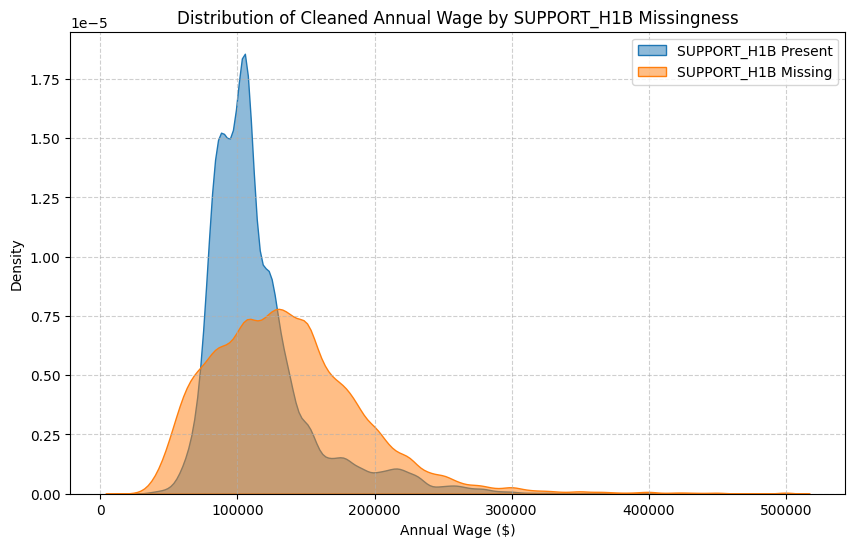

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create two groups based on the missingness of 'SUPPORT_H1B'
h1b_support_missing = h1b[h1b['SUPPORT_H1B'].isnull()]
h1b_support_present = h1b[h1b['SUPPORT_H1B'].notnull()]

# Calculate median annual_wage_cleaned for both groups
median_wage_missing = h1b_support_missing['annual_wage_cleaned'].median()
median_wage_present = h1b_support_present['annual_wage_cleaned'].median()

print(f"Median annual wage when SUPPORT_H1B is missing: ${median_wage_missing:,.2f}")
print(f"Median annual wage when SUPPORT_H1B is present: ${median_wage_present:,.2f}")

# Plotting the distributions using KDE plots for better comparison of densities
plt.figure(figsize=(10, 6))
sns.kdeplot(h1b_support_present['annual_wage_cleaned'].dropna(), label='SUPPORT_H1B Present', fill=True, alpha=0.5)
sns.kdeplot(h1b_support_missing['annual_wage_cleaned'].dropna(), label='SUPPORT_H1B Missing', fill=True, alpha=0.5)
plt.title('Distribution of Cleaned Annual Wage by SUPPORT_H1B Missingness')
plt.xlabel('Annual Wage ($)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Problem 5: Missing data and joins

**Part (c):** Based on your findings in part (b), do you think the missing values in the column you chose are MCAR (missing completely at random), MAR (missing at random, i.e., related to other observed variables), or MNAR (missing not at random)? There may not be a single correct answer — justify your reasoning in 2–3 sentences. What would go wrong if you simply dropped all rows with missing values before computing summary statistics?

---

Based on the finding that the distribution of `annual_wage_cleaned` is nearly identical whether `SUPPORT_H1B` is present or missing, it suggests that the missingness of `SUPPORT_H1B` is **Missing Completely At Random (MCAR)** with respect to `annual_wage_cleaned`. If it were MAR or MNAR related to wages, we would expect to see a noticeable difference in the wage distributions. If we were to simply drop all rows with missing values (including those for `SUPPORT_H1B`), it would not bias our wage analysis significantly *if the missingness truly is MCAR for wages*, but it would unnecessarily reduce the sample size, potentially affecting the precision of our estimates or our ability to analyze other variables where this column's missingness might not be MCAR.

## Problem 5: Missing data and joins - Part (d) Analysis

Number of H-1B filings that matched a BLS code: 62,054

Summary statistics of wage comparison (H-1B wage vs. National Median):


,annual_wage_cleaned,national_median_wage,wage_difference,wage_percentage_difference
count,62054.000000,62054.000000,62054.000000,62054.000000
mean,138505.963856,118852.656718,19653.307137,17.292341
std,44335.082366,17896.916456,41305.509230,35.884774
min,33259.000000,57890.000000,-79017.840000,-62.407424
25%,105997.000000,97430.000000,-12025.000000,-10.304019
50%,130000.000000,127260.000000,12589.000000,10.892582
75%,164400.000000,127260.000000,43240.000000,37.613671
max,500000.000000,164070.000000,372740.000000,319.059132



Wage comparison by Job Category (SOC_TITLE_BLS):


,SOC_TITLE_BLS,h1b_median_wage,bls_median_wage,num_filings,wage_difference,wage_percentage_difference
5,Computer and IS Managers,196000.0,164070,2977,31930.0,19.461206
6,Management Analysts,125798.0,99410,1145,26388.0,26.544613
4,Computer User Support Specialists,80000.0,57890,41,22110.0,38.193125
0,Accountants and Auditors,100000.0,79880,1563,20120.0,25.187782
2,"Computer Occupations, All Other",116200.0,97430,13030,18770.0,19.265113
3,Computer Systems Analysts,109429.0,99270,3557,10159.0,10.233706
7,Network/Systems Administrators,99091.0,90520,928,8571.0,9.468626
8,Software Developers,135000.0,127260,38354,7740.0,6.082037
1,Computer Network Architects,134202.0,126900,459,7302.0,5.754137


/tmp/ipykernel_4005/4268924621.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


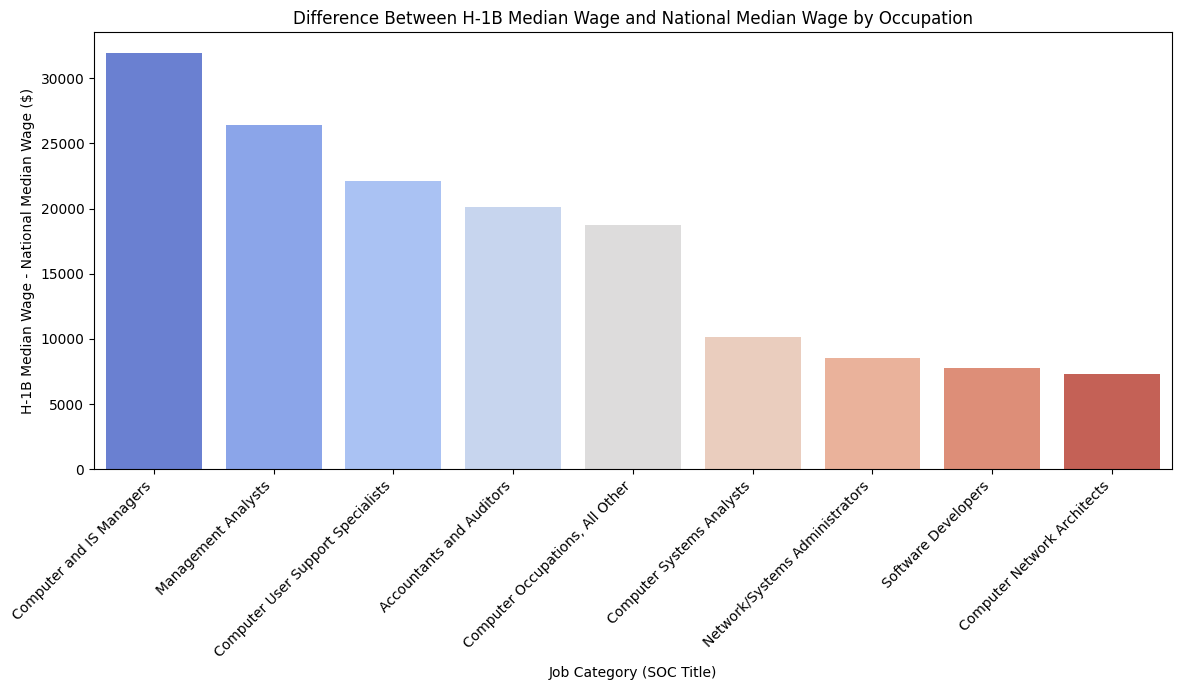

In [14]:
# BLS national median wages by SOC code (2023 OES survey, selected codes)
bls_wages = pd.DataFrame({
    'SOC_6': ['15-1252', '15-1211', '15-1299', '15-1244', '15-1232',
              '11-3021', '13-1111', '13-2011', '15-1241', '15-1256'],
    'SOC_TITLE_BLS': ['Software Developers', 'Computer Systems Analysts',
                      'Computer Occupations, All Other', 'Network/Systems Administrators',
                      'Computer User Support Specialists', 'Computer and IS Managers',
                      'Management Analysts', 'Accountants and Auditors',
                      'Computer Network Architects', 'Software Quality Assurance Analysts'],
    'national_median_wage': [127260, 99270, 97430, 90520, 57890,
                             164070, 99410, 79880, 126900, 98220],
})

# Clean SOC_CODE in h1b to match bls_wages format
h1b['SOC_6'] = h1b['SOC_CODE'].str.split('.').str[0]

# Merge h1b with bls_wages on SOC_6
merged_df = pd.merge(
    h1b.dropna(subset=['annual_wage_cleaned']), # Use cleaned wages and drop NaNs
    bls_wages,
    on='SOC_6',
    how='inner' # Use inner join to only keep matched SOC codes
)

print(f"Number of H-1B filings that matched a BLS code: {len(merged_df):,}")

# Compare H-1B annual_wage_cleaned to national_median_wage
# Calculate the difference and percentage difference
merged_df['wage_difference'] = merged_df['annual_wage_cleaned'] - merged_df['national_median_wage']
merged_df['wage_percentage_difference'] = (merged_df['wage_difference'] / merged_df['national_median_wage']) * 100

# Display summary statistics of the comparison
print("\nSummary statistics of wage comparison (H-1B wage vs. National Median):")
display(merged_df[['annual_wage_cleaned', 'national_median_wage', 'wage_difference', 'wage_percentage_difference']].describe())

# Compare across job categories (SOC_TITLE_BLS)
comparison_by_soc = merged_df.groupby('SOC_TITLE_BLS').agg(
    h1b_median_wage=('annual_wage_cleaned', 'median'),
    bls_median_wage=('national_median_wage', 'first'), # 'first' is fine as national_median_wage is constant per SOC_TITLE_BLS
    num_filings=('CASE_NUMBER', 'count')
).reset_index()
comparison_by_soc['wage_difference'] = comparison_by_soc['h1b_median_wage'] - comparison_by_soc['bls_median_wage']
comparison_by_soc['wage_percentage_difference'] = (comparison_by_soc['wage_difference'] / comparison_by_soc['bls_median_wage']) * 100

print("\nWage comparison by Job Category (SOC_TITLE_BLS):")
display(comparison_by_soc.sort_values(by='wage_difference', ascending=False))

# Plot the comparison for top job categories
plt.figure(figsize=(12, 7))
sns.barplot(
x='SOC_TITLE_BLS',
y='wage_difference',
data=comparison_by_soc.sort_values('wage_difference', ascending=False),
palette='coolwarm'
)
plt.axhline(0, color='black', linestyle='--', linewidth=0.7) # Add a line at 0 for reference
plt.ylabel('H-1B Median Wage - National Median Wage ($)')
plt.xlabel('Job Category (SOC Title)')
plt.title('Difference Between H-1B Median Wage and National Median Wage by Occupation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Problem 5: Missing Data and Joins

### Part (d)

The `SOC_CODE` column contains Standard Occupational Classification codes (e.g., `15-1252.00` for “Software Developers”). The Bureau of Labor Statistics publishes national median wages by SOC code. The reference table `bls_wages` uses 6-digit codes (without the `.00` suffix).

A common critique of the H-1B program is that employers use it to hire foreign workers at wages below the domestic market rate. We joined the H-1B filings with `bls_wages` to test this claim. We then compared H-1B `annual_wage` values to the `national_median_wage` for matched occupations.

---

### How many filings match a BLS code?

A total of **62,054** H-1B filings matched a BLS `SOC_6` code from the reference `bls_wages` table. This represents a substantial portion of the cleaned H-1B dataset and provides a meaningful sample for comparison.

---

### Do H-1B filings tend to offer more or less than the national median?

Summary statistics from `merged_df` indicate that H-1B wages are generally **higher** than national median wages.

- The **mean wage difference** is **$19,653.31**
- The **median wage difference** is **$12,589.00**

These positive values suggest that, on average, H-1B `annual_wage_cleaned` tends to be **higher** than the `national_median_wage`.

The percentage differences support this conclusion:

- Mean percentage difference: **17.29%**
- Median percentage difference: **10.89%**

Overall, H-1B wages appear to exceed national median wages for these matched occupations.

---

### Does the answer differ across job categories?

Yes, wage differences vary across job categories.

- For all matched job categories, the **H-1B median wage exceeds the national median wage**.

- **Computer and Information Systems Managers (`11-3021`)** show the largest absolute difference: **$31,930 higher** (19.46% difference).

- **Computer User Support Specialists (`15-1232`)** show the largest percentage difference: **$22,110 higher** (38.19% difference).

- High-volume H-1B roles such as **Software Developers (`15-1252`)** and **Computer Network Architects (`15-1241`)** also show positive differences, though smaller. For example, Software Developers show **$7,740 higher wages** (6.08%).

These findings contradict the claim that H-1B workers are consistently paid below market rates—at least for the occupations included in this sample.

---

### Caveats Before Drawing Policy Conclusions

Several limitations should be considered:

1. **Limited SOC Coverage**  
   The `bls_wages` table contains only **10 SOC codes**, so results may not generalize across all occupations.

2. **National vs. Local Wages**  
   BLS data reports **national medians**, while H-1B workers are often concentrated in high-cost regions (e.g., California, Washington). Local wages may be more appropriate for comparison.

3. **Experience and Skill Levels**  
   H-1B workers may disproportionately occupy specialized or advanced roles that command higher wages than the overall occupational median.

4. **Offered vs. Actual Wages**  
   H-1B filings report **offered wages**, which may differ from actual compensation.

5. **Data Cleaning Effects**  
   Extreme outliers were removed, which improves analysis but may slightly influence overall results.

6. **Market Rate Complexity**  
   The national median wage does not account for factors such as industry, company size, or specialized skills.